# 03 Extension: Grade-Level Comparison

This notebook performs a descriptive extension analysis for Cycle 3.

Main analysis question:
- Is current alcohol use different between male and female students overall?

Extension question:
- Does the male-female pattern look consistent across grade levels?

This is a descriptive stratified analysis, not an additional formal hypothesis test.

## 1. Import libraries and set paths

This notebook uses the cleaned extension data created by `01_data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

project_dir = Path("..")

cleaned_extension_path = project_dir / "data" / "processed" / "cycle3_cleaned_grade_extension.csv"

figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"
summary_dir = project_dir / "outputs" / "summary"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)

print("Looking for cleaned extension data:")
print(cleaned_extension_path)
print("File exists?", cleaned_extension_path.exists())

Looking for cleaned extension data:
..\data\processed\cycle3_cleaned_grade_extension.csv
File exists? True


## 2. Load cleaned extension data

Expected columns:
- `grade_level`
- `sex_group`
- `current_alcohol_use`

In [2]:
df = pd.read_csv(cleaned_extension_path)

print("Cleaned extension data shape:", df.shape)
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nGrade counts:")
display(df["grade_level"].value_counts().sort_index())

print("\nSex counts:")
display(df["sex_group"].value_counts())

print("\nCurrent alcohol use counts:")
display(df["current_alcohol_use"].value_counts().sort_index())

Cleaned extension data shape: (12600, 3)


,grade_level,sex_group,current_alcohol_use
0,9th grade,Female,0
1,11th grade,Female,0
2,11th grade,Female,0
3,11th grade,Female,0
4,11th grade,Female,0



Column names:
['grade_level', 'sex_group', 'current_alcohol_use']

Grade counts:


grade_level
10th grade    3122
11th grade    3164
12th grade    3233
9th grade     3081
Name: count, dtype: int64


Sex counts:


sex_group
Female    6402
Male      6198
Name: count, dtype: int64


Current alcohol use counts:


current_alcohol_use
0    6916
1    5684
Name: count, dtype: int64

## 3. Create grade-by-sex summary table

For each grade and sex group, calculate:
- sample size
- number of current alcohol users
- current alcohol use proportion
- current alcohol use percentage

In [3]:
grade_summary = (
    df
    .groupby(["grade_level", "sex_group"])
    .agg(
        sample_size=("current_alcohol_use", "count"),
        alcohol_users=("current_alcohol_use", "sum"),
        alcohol_use_proportion=("current_alcohol_use", "mean")
    )
    .reset_index()
)

grade_summary["alcohol_use_percent"] = grade_summary["alcohol_use_proportion"] * 100

grade_summary = grade_summary.sort_values(["grade_level", "sex_group"])

display(grade_summary)

,grade_level,sex_group,sample_size,alcohol_users,alcohol_use_proportion,alcohol_use_percent
0,10th grade,Female,1572,662,0.421120,42.111959
1,10th grade,Male,1550,670,0.432258,43.225806
2,11th grade,Female,1687,750,0.444576,44.457617
3,11th grade,Male,1477,739,0.500339,50.033852
4,12th grade,Female,1622,826,0.509248,50.924784
5,12th grade,Male,1611,886,0.549969,54.996896
6,9th grade,Female,1521,613,0.403024,40.302433
7,9th grade,Male,1560,538,0.344872,34.487179


In [4]:
grade_summary.to_csv(
    tables_dir / "grade_level_alcohol_by_gender_summary.csv",
    index=False
)

print("Saved table:")
print(tables_dir / "grade_level_alcohol_by_gender_summary.csv")

Saved table:
..\outputs\tables\grade_level_alcohol_by_gender_summary.csv


## 4. Calculate male-female difference within each grade

Difference is defined as:

\[
\text{Male proportion} - \text{Female proportion}
\]

Positive value:
- Male proportion is higher.

Negative value:
- Female proportion is higher.

In [5]:
grade_pivot = grade_summary.pivot(
    index="grade_level",
    columns="sex_group",
    values="alcohol_use_proportion"
)

grade_pivot["Difference_Male_minus_Female"] = grade_pivot["Male"] - grade_pivot["Female"]
grade_pivot["Difference_percentage_points"] = grade_pivot["Difference_Male_minus_Female"] * 100

display(grade_pivot)

sex_group,Female,Male,Difference_Male_minus_Female,Difference_percentage_points
grade_level,,,,
10th grade,0.421120,0.432258,0.011138,1.113847
11th grade,0.444576,0.500339,0.055762,5.576235
12th grade,0.509248,0.549969,0.040721,4.072112
9th grade,0.403024,0.344872,-0.058153,-5.815253


In [6]:
grade_pivot.to_csv(
    tables_dir / "grade_level_gender_difference.csv"
)

print("Saved table:")
print(tables_dir / "grade_level_gender_difference.csv")

Saved table:
..\outputs\tables\grade_level_gender_difference.csv


## 5. Grouped bar chart

This chart compares current alcohol use percentages for male and female students within each grade level.

In [7]:
grade_order = ["9th grade", "10th grade", "11th grade", "12th grade"]

plot_data = grade_summary.copy()
plot_data["grade_level"] = pd.Categorical(
    plot_data["grade_level"],
    categories=grade_order,
    ordered=True
)

plot_data = plot_data.sort_values(["grade_level", "sex_group"])

pivot_percent = plot_data.pivot(
    index="grade_level",
    columns="sex_group",
    values="alcohol_use_percent"
).loc[grade_order]

display(pivot_percent)

sex_group,Female,Male
grade_level,,
9th grade,40.302433,34.487179
10th grade,42.111959,43.225806
11th grade,44.457617,50.033852
12th grade,50.924784,54.996896


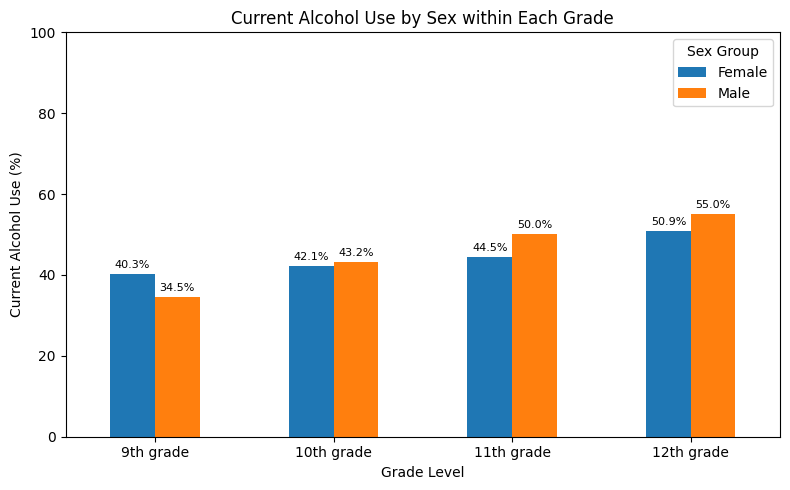

Saved figure:
..\outputs\figures\grade_level_alcohol_by_gender.png


In [8]:
ax = pivot_percent.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Grade Level")
plt.ylabel("Current Alcohol Use (%)")
plt.title("Current Alcohol Use by Sex within Each Grade")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Sex Group")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.tight_layout()

output_path = figures_dir / "grade_level_alcohol_by_gender.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(output_path)

## 6. Difference plot

This chart shows the male-female difference in percentage points within each grade.

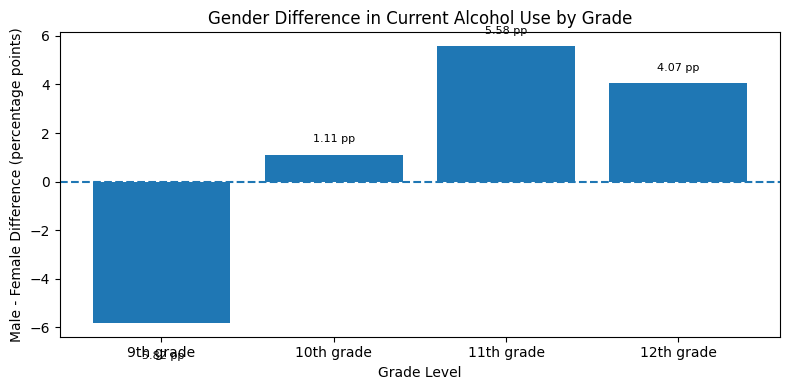

Saved figure:
..\outputs\figures\grade_level_gender_difference.png


In [9]:
difference_pp = grade_pivot.loc[grade_order, "Difference_percentage_points"]

plt.figure(figsize=(8, 4))

plt.bar(difference_pp.index, difference_pp.values)
plt.axhline(0, linestyle="--")

plt.xlabel("Grade Level")
plt.ylabel("Male - Female Difference (percentage points)")
plt.title("Gender Difference in Current Alcohol Use by Grade")

for i, value in enumerate(difference_pp.values):
    label_y = value + 0.5 if value >= 0 else value - 1.5
    plt.text(i, label_y, f"{value:.2f} pp", ha="center", fontsize=8)

plt.tight_layout()

output_path = figures_dir / "grade_level_gender_difference.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(output_path)

## 7. Write extension interpretation

Use this text in README, report, or poster notes.

In [10]:
# Basic automatic interpretation
max_abs_diff = grade_pivot["Difference_percentage_points"].abs().max()
avg_abs_diff = grade_pivot["Difference_percentage_points"].abs().mean()

extension_summary = f"""
# Extension Analysis: Grade-Level Comparison

This extension compares current alcohol use proportions between male and female students within each grade level.

The purpose is not to replace the main two-proportion z-test. Instead, this descriptive analysis checks whether the overall male-female pattern is consistent across grade levels.

The largest absolute male-female difference across grades is {max_abs_diff:.2f} percentage points, and the average absolute difference across grades is {avg_abs_diff:.2f} percentage points.

This extension helps us interpret the main result more carefully. If the differences within grade levels are small, it supports the main conclusion that the overall gender difference is limited. If the differences vary across grades, it suggests that grade level may be an important context when discussing current alcohol use patterns.
"""

summary_path = summary_dir / "extension_grade_level_summary.md"
summary_path.write_text(extension_summary, encoding="utf-8")

print(extension_summary)
print("\nSaved summary:")
print(summary_path)


# Extension Analysis: Grade-Level Comparison

This extension compares current alcohol use proportions between male and female students within each grade level.

The purpose is not to replace the main two-proportion z-test. Instead, this descriptive analysis checks whether the overall male-female pattern is consistent across grade levels.

The largest absolute male-female difference across grades is 5.82 percentage points, and the average absolute difference across grades is 4.14 percentage points.

This extension helps us interpret the main result more carefully. If the differences within grade levels are small, it supports the main conclusion that the overall gender difference is limited. If the differences vary across grades, it suggests that grade level may be an important context when discussing current alcohol use patterns.


Saved summary:
..\outputs\summary\extension_grade_level_summary.md


## 8. Final files produced by this notebook

Tables:
- `outputs/tables/grade_level_alcohol_by_gender_summary.csv`
- `outputs/tables/grade_level_gender_difference.csv`

Figures:
- `outputs/figures/grade_level_alcohol_by_gender.png`
- `outputs/figures/grade_level_gender_difference.png`

Summary:
- `outputs/summary/extension_grade_level_summary.md`